# Brechas cambiarias en Argentina: análisis del dataset propio

Este notebook analiza la serie temporal que construye el pipeline del repo
(3 corridas diarias vía GitHub Actions, ver README). **Está pensado para
re-ejecutarse a medida que la base crece**: con pocos días de datos muestra la
foto actual, y las secciones de series y volatilidad se activan solas cuando
hay historia suficiente.

### ¿Por qué existen "muchos dólares" en Argentina?

Argentina convive hace décadas con regímenes cambiarios cambiantes: períodos con
restricciones a la compra de divisas ("cepo"), impuestos sobre el dólar para
consumo, y mercados paralelos —legales e informales— que surgen para esquivar
esas fricciones. El resultado es que un mismo dólar cotiza a varios precios a la
vez:

| Tipo | Qué es |
|---|---|
| **Oficial** | El del banco, minorista. Referencia para comercio exterior y precios. |
| **Mayorista** | El de los bancos y grandes empresas entre sí; el que interviene el BCRA. |
| **Blue** | El informal, de compraventa en efectivo. Sin registro. |
| **MEP** (o "bolsa") | Legal: se compra un bono en pesos y se vende en dólares. |
| **CCL** | Como el MEP, pero los dólares quedan en una cuenta fuera del país. |
| **Cripto** | El implícito en comprar stablecoins (USDT/USDC) con pesos en exchanges. |
| **Tarjeta** | El oficial más los impuestos que pagan los consumos en el exterior. |

**La brecha** —el porcentaje en que un dólar alternativo supera al oficial— es un
termómetro de expectativas: cuando el mercado espera devaluación o hay más pesos
buscando salida, la brecha se ensancha. En el pico del cepo (2020–2023) superó el
100%; en regímenes más liberados se comprime a un dígito.

In [1]:
import sys
sys.path.append("..")

import sqlite3
import pandas as pd

from src import viz
from src.db import RUTA_DB

viz.aplicar_estilo()
pd.options.display.float_format = "{:,.2f}".format

TZ_ARG = "America/Argentina/Buenos_Aires"

conexion = sqlite3.connect(RUTA_DB)

dolar = pd.read_sql("SELECT * FROM cotizaciones_dolar", conexion, parse_dates=["timestamp_utc"])
cripto = pd.read_sql("SELECT * FROM precios_cripto", conexion, parse_dates=["timestamp_utc"])

# Pasamos los timestamps de la corrida a hora argentina
for df in (dolar, cripto):
    df["momento"] = df["timestamp_utc"].dt.tz_convert(TZ_ARG)
    df["fecha"] = df["momento"].dt.date

corridas = dolar["timestamp_utc"].nunique()
dias = dolar["fecha"].nunique()
print(f"Corridas acumuladas: {corridas} | Días con datos: {dias}")
print(f"Desde {dolar['momento'].min():%Y-%m-%d %H:%M} hasta {dolar['momento'].max():%Y-%m-%d %H:%M} (hora AR)")

Corridas acumuladas: 2 | Días con datos: 1
Desde 2026-07-14 15:15 hasta 2026-07-14 15:16 (hora AR)


## 1. Foto actual: cotizaciones y brechas de la última corrida

Esta sección funciona desde la primera corrida. La brecha de cada tipo de
dólar se calcula contra el **oficial** usando el precio de venta:

$$\text{brecha} = \left(\frac{\text{venta}_{tipo}}{\text{venta}_{oficial}} - 1\right) \times 100$$

In [2]:
# Última corrida completa
ultima = dolar[dolar["timestamp_utc"] == dolar["timestamp_utc"].max()].copy()
venta_oficial = ultima.loc[ultima["tipo"] == "oficial", "venta"].iloc[0]

ultima["brecha_%"] = (ultima["venta"] / venta_oficial - 1) * 100
ultima["nombre"] = ultima["tipo"].map(viz.NOMBRES_DOLARES)

tabla_actual = (
    ultima[["nombre", "compra", "venta", "brecha_%"]]
    .sort_values("venta")
    .set_index("nombre")
)
print(f"Última corrida: {ultima['momento'].iloc[0]:%Y-%m-%d %H:%M} (hora AR)")
tabla_actual

Última corrida: 2026-07-14 15:16 (hora AR)


,compra,venta,brecha_%
nombre,,,
Mayorista,"1,464.00","1,473.00",-1.80
Oficial,"1,450.00","1,500.00",0.00
MEP,"1,510.60","1,513.10",0.87
Blue,"1,500.00","1,520.00",1.33
Cripto,"1,554.94","1,557.31",3.82
CCL,"1,559.60","1,560.40",4.03
Tarjeta,"1,885.00","1,950.00",30.00


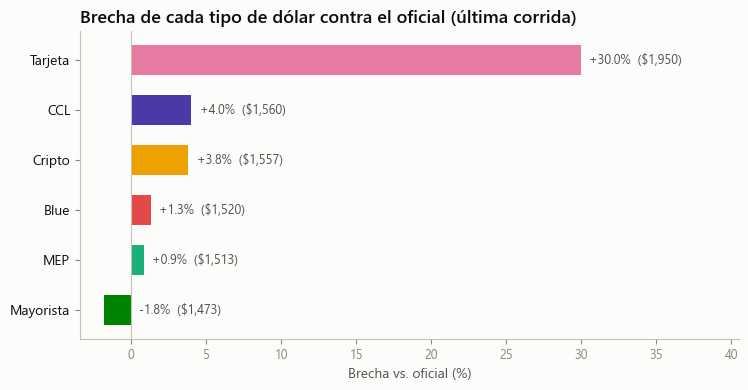

In [3]:
import matplotlib.pyplot as plt

# Brechas actuales contra el oficial (excluimos al oficial, brecha 0 por definición)
con_brecha = ultima[ultima["tipo"] != "oficial"].sort_values("brecha_%")

fig, ax = plt.subplots(figsize=(8.5, 4))
colores = [viz.PALETA_DOLARES[t] for t in con_brecha["tipo"]]
ax.barh(con_brecha["nombre"], con_brecha["brecha_%"], color=colores, height=0.6)

for i, (brecha, venta) in enumerate(zip(con_brecha["brecha_%"], con_brecha["venta"])):
    ax.annotate(
        f"{brecha:+.1f}%  (${venta:,.0f})",
        xy=(max(brecha, 0), i), xytext=(6, 0), textcoords="offset points",
        va="center", fontsize=9, color=viz.TINTA_SECUNDARIA,
    )

ax.set_title("Brecha de cada tipo de dólar contra el oficial (última corrida)")
ax.set_xlabel("Brecha vs. oficial (%)")
ax.set_xlim(right=con_brecha["brecha_%"].max() * 1.35)
ax.grid(visible=False)
ax.axvline(0, color=viz.EJE, linewidth=0.8)
ax.tick_params(axis="y", labelsize=10, labelcolor=viz.TINTA)
viz.guardar_figura(fig, "01_brechas_actuales");

Lecturas rápidas de la foto (los valores exactos cambian con cada corrida):

- El **tarjeta** siempre queda arriba: no es un precio de mercado sino el
  oficial más impuestos — la distancia con el resto mide cuánto castiga el
  esquema impositivo al consumo en el exterior.
- **MEP, CCL, blue y cripto** son los precios "de salida" del peso. Cuando el
  régimen cambiario está liberado, se pegan al oficial (brechas de un dígito);
  si se tensiona, se despegan.
- El **CCL suele correr por encima del MEP**: esa diferencia ("el canje") es el
  costo de girar los dólares afuera del país.

## 2. Evolución de cotizaciones y brechas

Estas series se activan cuando hay al menos **3 días** de datos acumulados.

In [4]:
MIN_DIAS_SERIE = 3

# Serie de venta por tipo, una observación por corrida
serie_venta = dolar.pivot_table(index="momento", columns="tipo", values="venta")

TIPOS_SERIE = ["oficial", "blue", "bolsa", "contadoconliqui", "cripto"]

if dias >= MIN_DIAS_SERIE:
    fig, ax = plt.subplots(figsize=(9.5, 4.8))
    for tipo in TIPOS_SERIE:
        if tipo not in serie_venta.columns:
            continue
        s = serie_venta[tipo].dropna()
        ax.plot(s.index, s.values, color=viz.PALETA_DOLARES[tipo], linewidth=2)
        viz.etiqueta_directa(ax, s.index[-1], s.iloc[-1],
                             viz.NOMBRES_DOLARES[tipo], viz.PALETA_DOLARES[tipo])
    ax.set_title("Evolución del precio de venta por tipo de dólar")
    ax.set_ylabel("ARS por USD (venta)")
    ax.grid(axis="x", visible=False)
    viz.guardar_figura(fig, "02_evolucion_cotizaciones")
else:
    print(f"Serie todavía corta ({dias} día/s de datos; se necesitan {MIN_DIAS_SERIE}).")
    print("Cuando el pipeline acumule más corridas, esta celda va a dibujar la")
    print("evolución de oficial, blue, MEP, CCL y cripto, cada uno con su color.")

Serie todavía corta (1 día/s de datos; se necesitan 3).
Cuando el pipeline acumule más corridas, esta celda va a dibujar la
evolución de oficial, blue, MEP, CCL y cripto, cada uno con su color.


In [5]:
# Brechas en el tiempo: blue, MEP y CCL contra oficial + el "canje" CCL/MEP
brechas = pd.DataFrame(index=serie_venta.index)
for tipo in ["blue", "bolsa", "contadoconliqui"]:
    if tipo in serie_venta.columns:
        brechas[tipo] = (serie_venta[tipo] / serie_venta["oficial"] - 1) * 100
canje = (serie_venta["contadoconliqui"] / serie_venta["bolsa"] - 1) * 100

if dias >= MIN_DIAS_SERIE:
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    for tipo in brechas.columns:
        s = brechas[tipo].dropna()
        ax.plot(s.index, s.values, color=viz.PALETA_DOLARES[tipo], linewidth=2)
        viz.etiqueta_directa(ax, s.index[-1], s.iloc[-1],
                             viz.NOMBRES_DOLARES[tipo], viz.PALETA_DOLARES[tipo])
    ax.set_title("Evolución de la brecha contra el dólar oficial")
    ax.set_ylabel("Brecha (%)")
    ax.axhline(0, color=viz.EJE, linewidth=0.8)
    ax.grid(axis="x", visible=False)
    viz.guardar_figura(fig, "03_evolucion_brechas")
else:
    print("Serie corta: por ahora, últimos valores calculados —")
    print(f"  brecha blue: {brechas['blue'].iloc[-1]:+.1f}%")
    print(f"  brecha MEP:  {brechas['bolsa'].iloc[-1]:+.1f}%")
    print(f"  brecha CCL:  {brechas['contadoconliqui'].iloc[-1]:+.1f}%")
    print(f"  canje CCL/MEP: {canje.iloc[-1]:+.1f}%")

Serie corta: por ahora, últimos valores calculados —
  brecha blue: +1.3%
  brecha MEP:  +0.9%
  brecha CCL:  +4.0%
  canje CCL/MEP: +3.1%


## 3. Dólar cripto vs. el precio implícito de USDT

USDT es una stablecoin que vale ~1 USD. Con los datos de CoinGecko podemos
calcular a cuántos pesos equivale un dólar "vía USDT":

$$\text{USDT implícito} = \frac{\text{precio USDT en ARS}}{\text{precio USDT en USD}}$$

La comparación con el **dólar cripto** de DolarAPI (que releva el precio real de
comprar stablecoins en exchanges argentinos) es más interesante de lo que parece:
CoinGecko convierte a pesos usando un tipo de cambio de referencia global,
mientras que el dólar cripto refleja lo que efectivamente se paga en el mercado
local. **La diferencia entre ambos revela qué tipo de cambio usa el agregador
global — y cuánto premium paga el comprador argentino.**

In [6]:
usdt = cripto[cripto["moneda"] == "USDT"].set_index("timestamp_utc")
usdt_implicito = (usdt["precio_ars"] / usdt["precio_usd"]).rename("usdt_implicito")

dolar_cripto = (
    dolar[dolar["tipo"] == "cripto"].set_index("timestamp_utc")["venta"].rename("dolar_cripto")
)

# Cruzamos por corrida (mismo timestamp) e informamos la diferencia
comparacion = pd.concat([usdt_implicito, dolar_cripto], axis=1, join="inner")
comparacion["diferencia_%"] = (
    (comparacion["dolar_cripto"] / comparacion["usdt_implicito"]) - 1
) * 100

ultima_comp = comparacion.iloc[-1]
print(f"USDT implícito (CoinGecko): ${ultima_comp['usdt_implicito']:,.0f}")
print(f"Dólar cripto (DolarAPI):    ${ultima_comp['dolar_cripto']:,.0f}")
print(f"Diferencia: {ultima_comp['diferencia_%']:+.1f}%")
comparacion.tail()

USDT implícito (CoinGecko): $1,470
Dólar cripto (DolarAPI):    $1,557
Diferencia: +5.9%


,usdt_implicito,dolar_cripto,diferencia_%
timestamp_utc,,,
2026-07-14 18:15:47+00:00,"1,470.50","1,557.31",5.90
2026-07-14 18:16:59+00:00,"1,470.49","1,557.31",5.90


In [7]:
if dias >= MIN_DIAS_SERIE:
    fig, ax = plt.subplots(figsize=(9.5, 4.5))
    ax.plot(comparacion.index, comparacion["dolar_cripto"],
            color=viz.PALETA_DOLARES["cripto"], linewidth=2)
    viz.etiqueta_directa(ax, comparacion.index[-1], comparacion["dolar_cripto"].iloc[-1],
                         "Dólar cripto", viz.PALETA_DOLARES["cripto"])
    ax.plot(comparacion.index, comparacion["usdt_implicito"],
            color=viz.AZUL, linewidth=2)
    viz.etiqueta_directa(ax, comparacion.index[-1], comparacion["usdt_implicito"].iloc[-1],
                         "USDT implícito", viz.AZUL)
    ax.set_title("Dólar cripto local vs. USDT implícito de CoinGecko")
    ax.set_ylabel("ARS por USD")
    ax.grid(axis="x", visible=False)
    viz.guardar_figura(fig, "04_cripto_vs_usdt")
else:
    print(f"Serie corta: el gráfico comparado se activa con {MIN_DIAS_SERIE}+ días de datos.")

Serie corta: el gráfico comparado se activa con 3+ días de datos.


## 4. Volatilidad comparada

¿Qué dólar se mueve más? Medimos la volatilidad como el **desvío estándar de las
variaciones porcentuales diarias** del precio de venta (tomando la última corrida
de cada día). Necesita al menos **6 días** de datos para decir algo con sentido —
y aún así, con pocas semanas es una medida gruesa.

In [8]:
MIN_DIAS_VOLATILIDAD = 6

# Última observación de cada día, por tipo
diario = (
    dolar.sort_values("momento")
    .groupby(["fecha", "tipo"], as_index=False).last()
    .pivot(index="fecha", columns="tipo", values="venta")
)

if dias >= MIN_DIAS_VOLATILIDAD:
    variaciones = diario.pct_change() * 100
    volatilidad = variaciones.std().dropna().sort_values()

    fig, ax = plt.subplots(figsize=(8.5, 4))
    colores = [viz.PALETA_DOLARES[t] for t in volatilidad.index]
    nombres = [viz.NOMBRES_DOLARES[t] for t in volatilidad.index]
    ax.barh(nombres, volatilidad.values, color=colores, height=0.6)
    for i, valor in enumerate(volatilidad.values):
        ax.annotate(f"{valor:.2f}", xy=(valor, i), xytext=(6, 0),
                    textcoords="offset points", va="center",
                    fontsize=9, color=viz.TINTA_SECUNDARIA)
    ax.set_title("Volatilidad diaria por tipo de dólar")
    ax.set_xlabel("Desvío estándar de la variación diaria (%)")
    ax.grid(visible=False)
    ax.tick_params(axis="y", labelsize=10, labelcolor=viz.TINTA)
    viz.guardar_figura(fig, "05_volatilidad")
else:
    print(f"Datos insuficientes: {dias} día/s (se necesitan {MIN_DIAS_VOLATILIDAD}).")
    print("Hipótesis a contrastar cuando haya serie: el oficial/mayorista deberían")
    print("ser los menos volátiles (los administra el BCRA) y el blue el más")
    print("ruidoso (mercado chico e informal, sensible a noticias).")

Datos insuficientes: 1 día/s (se necesitan 6).
Hipótesis a contrastar cuando haya serie: el oficial/mayorista deberían
ser los menos volátiles (los administra el BCRA) y el blue el más
ruidoso (mercado chico e informal, sensible a noticias).


## Cierre

Este notebook crece con el repo: cada corrida del pipeline agrega tres
observaciones diarias, y las secciones dormidas (series, volatilidad) se
despiertan solas al re-ejecutarlo. Ideas para profundizar cuando haya serie
acumulada — correlación entre brecha y eventos (anuncios económicos, licitaciones),
la brecha como predictor de movimientos del oficial, y sumar riesgo país e
inflación como fuentes nuevas (el diseño del pipeline lo hace directo: una
función de extracción + una tabla + una entrada en `FUENTES`).